### Data Analysis

In [1]:
from src.data_prep import CreditDataAnalyzer

In [2]:
# 1. Initialisation
analyzer = CreditDataAnalyzer()

In [3]:
# 2. Load data
df = analyzer.load_data()

✅ CSV dataset already exists locally.


In [4]:
# 3. Exploration and cleaning
analyzer.explore_basics()
analyzer.clean_data()


--- Basic Exploration ---
Dataset shape: (30000, 25)

Columns: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']

Missing values per column:
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT


Target distribution (%) :
 IsDefault
0    77.88
1    22.12
Name: proportion, dtype: float64


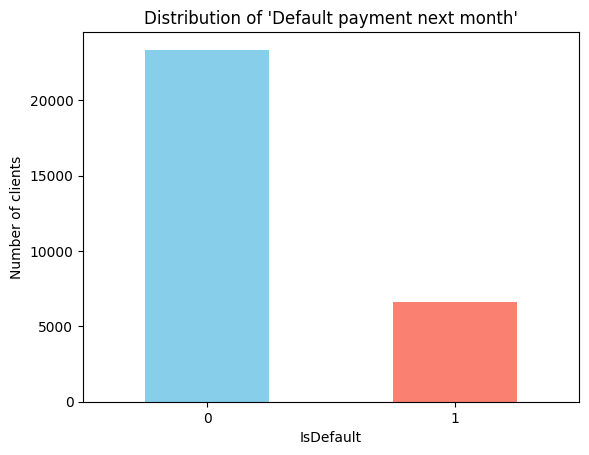


--- Bias check for feature 'SEX' ---
IsDefault         0         1
SEX                          
1          0.758328  0.241672
2          0.792237  0.207763


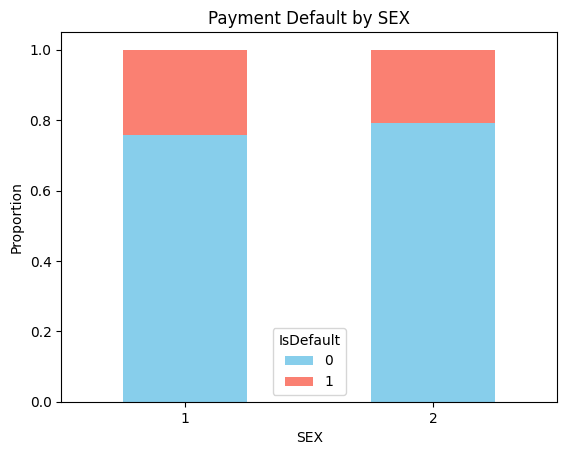


--- Bias check for feature 'EDUCATION' ---
IsDefault         0         1
EDUCATION                    
0          1.000000  0.000000
1          0.807652  0.192348
2          0.762651  0.237349
3          0.748424  0.251576
4          0.943089  0.056911
5          0.935714  0.064286
6          0.843137  0.156863


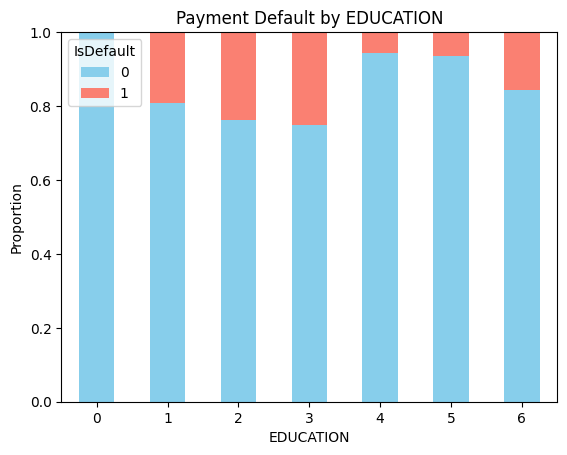


--- Bias check for feature 'MARRIAGE' ---
IsDefault         0         1
MARRIAGE                     
0          0.907407  0.092593
1          0.765283  0.234717
2          0.790717  0.209283
3          0.739938  0.260062


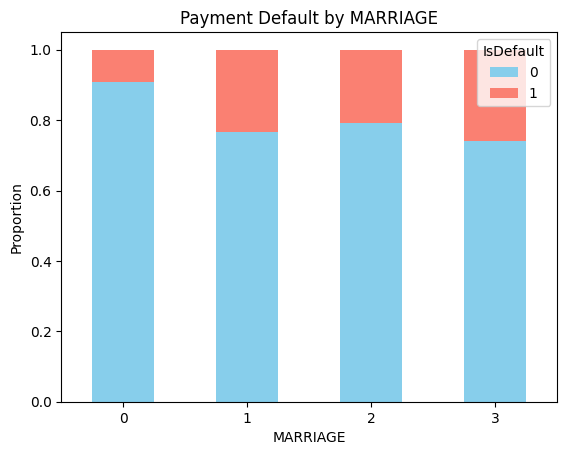


--- Bias check for feature 'AGE' ---
IsDefault         0         1
AGE                          
21         0.791045  0.208955
22         0.698214  0.301786
23         0.734694  0.265306
24         0.733807  0.266193
25         0.745363  0.254637
26         0.798567  0.201433
27         0.788084  0.211916
28         0.797019  0.202981
29         0.804984  0.195016
30         0.803584  0.196416
31         0.811832  0.188168
32         0.805699  0.194301
33         0.812391  0.187609
34         0.801205  0.198795
35         0.796945  0.203055
36         0.770758  0.229242
37         0.780019  0.219981
38         0.794492  0.205508
39         0.791405  0.208595
40         0.785057  0.214943
41         0.775485  0.224515
42         0.767003  0.232997
43         0.776119  0.223881
44         0.768571  0.231429
45         0.811994  0.188006
46         0.724561  0.275439
47         0.760479  0.239521
48         0.776824  0.223176
49         0.736726  0.263274
50         0.754258  0.245742
51

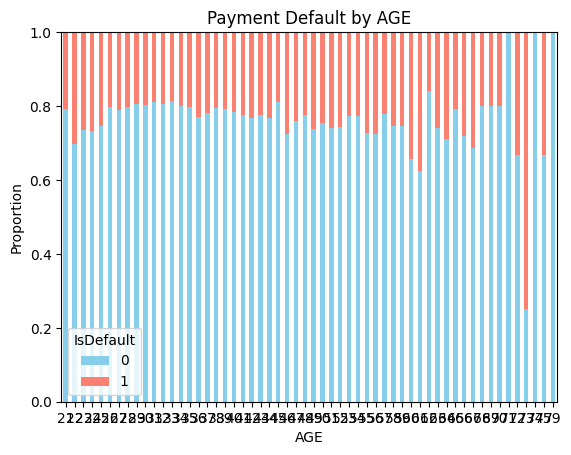

In [5]:
# 4. Visualisations (EDA)
analyzer.plot_target_distribution()
analyzer.check_bias(feature='SEX')
analyzer.check_bias(feature='EDUCATION')
analyzer.check_bias(feature='MARRIAGE')
analyzer.check_bias(feature='AGE')


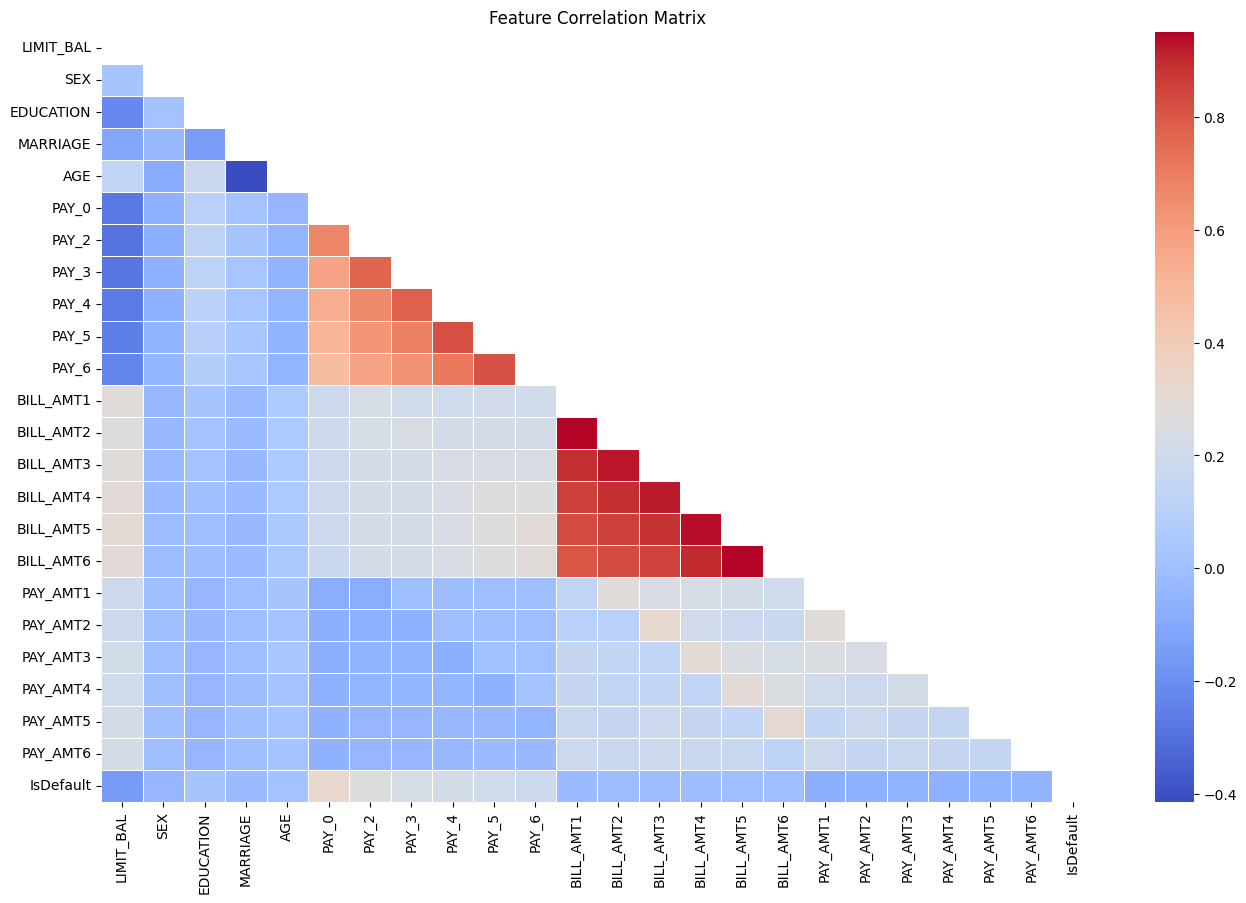

In [6]:
analyzer.plot_correlation_matrix() 

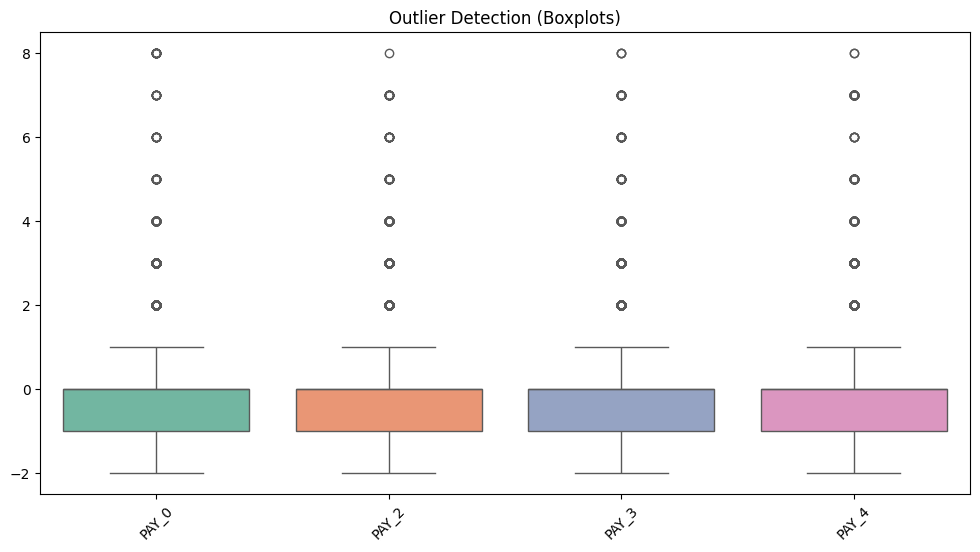

In [7]:
# Exemple d'utilisation de la fonction bonus d'outliers sur quelques features d'historique de paiement
analyzer.plot_feature_boxplot(features=['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4']) 


In [8]:
X_train, X_test, y_train, y_test = analyzer.prepare_for_modeling()
weights = analyzer.compute_model_weights()


--- Machine Learning Preparation ---
Data split and standardized successfully!
Training set size: (24000, 23)
Test set size: (6000, 23)

--- Recommended weights to handle class imbalance ---
Class 0 -> 0.64
Class 1 -> 2.26


In [9]:
%load_ext autoreload
%autoreload 2

from src.model import train_model, evaluate_model

In [10]:

trained_model = train_model(
    X_train, 
    y_train, 
    epochs=300, 
    start_lr=0.01, 
    class_weights=weights
)


accuracy = evaluate_model(trained_model, X_test, y_test)


Starting PyTorch model training with Regularization...
Initial LR: 0.01, Epochs: 300, Dropout: 0.3
Epoch [20/300], Loss: 0.9124, Current LR: 0.009891
Epoch [40/300], Loss: 0.8870, Current LR: 0.009568
Epoch [60/300], Loss: 0.8759, Current LR: 0.009046
Epoch [80/300], Loss: 0.8688, Current LR: 0.008347
Epoch [100/300], Loss: 0.8637, Current LR: 0.007503
Epoch [120/300], Loss: 0.8587, Current LR: 0.006549
Epoch [140/300], Loss: 0.8562, Current LR: 0.005527
Epoch [160/300], Loss: 0.8554, Current LR: 0.004483
Epoch [180/300], Loss: 0.8494, Current LR: 0.003461
Epoch [200/300], Loss: 0.8479, Current LR: 0.002508
Epoch [220/300], Loss: 0.8454, Current LR: 0.001663
Epoch [240/300], Loss: 0.8481, Current LR: 0.000964
Epoch [260/300], Loss: 0.8443, Current LR: 0.000442
Epoch [280/300], Loss: 0.8470, Current LR: 0.000119
Epoch [300/300], Loss: 0.8428, Current LR: 0.000010
Accuracy on test set: 73.65%

--- Classification Report ---
              precision    recall  f1-score   support

         

In [11]:
optimized_model = train_model(
    X_train, 
    y_train, 
    epochs=300,      
    start_lr=0.01,    # High initial LR to learn fast
    class_weights=weights,
    dropout_p=0.4     # 40% dropout to fight overfitting
)

# Final evaluation
print("\n--- RESULTS WITH DROPOUT AND SCHEDULER ---")
evaluate_model(optimized_model, X_test, y_test)


Starting PyTorch model training with Regularization...
Initial LR: 0.01, Epochs: 300, Dropout: 0.4
Epoch [20/300], Loss: 0.9252, Current LR: 0.009891
Epoch [40/300], Loss: 0.8989, Current LR: 0.009568
Epoch [60/300], Loss: 0.8877, Current LR: 0.009046
Epoch [80/300], Loss: 0.8770, Current LR: 0.008347
Epoch [100/300], Loss: 0.8711, Current LR: 0.007503
Epoch [120/300], Loss: 0.8706, Current LR: 0.006549
Epoch [140/300], Loss: 0.8626, Current LR: 0.005527
Epoch [160/300], Loss: 0.8607, Current LR: 0.004483
Epoch [180/300], Loss: 0.8596, Current LR: 0.003461
Epoch [200/300], Loss: 0.8609, Current LR: 0.002508
Epoch [220/300], Loss: 0.8606, Current LR: 0.001663
Epoch [240/300], Loss: 0.8551, Current LR: 0.000964
Epoch [260/300], Loss: 0.8565, Current LR: 0.000442
Epoch [280/300], Loss: 0.8580, Current LR: 0.000119
Epoch [300/300], Loss: 0.8576, Current LR: 0.000010

--- RESULTS WITH DROPOUT AND SCHEDULER ---
Accuracy on test set: 73.78%

--- Classification Report ---
              precis

0.7378333333333333

In [12]:
from src.fairness import evaluate_fairness, get_sample_weights, plot_fairness_comparison, get_combined_weights

In [13]:
mf_before = evaluate_fairness(optimized_model, X_test, y_test)


fairness_weights = get_sample_weights(X_train, y_train)


print("\n--- Training ---")
fair_model = train_model(
    X_train, 
    y_train, 
    epochs=300, 
    start_lr=0.01, 
    instance_weights=fairness_weights, 
    dropout_p=0.4
)


print("\n--- New Model ---")
mf_after = evaluate_fairness(fair_model, X_test, y_test)


print("\n--- Performance ---")
evaluate_model(fair_model, X_test, y_test)

Starting Fairness Audit
Prediction rate of 'Default' for Men : 36.18%
Prediction rate of 'Default' for Women : 29.10%
Demographic Parity Difference: 7.08%
ALERT: The model is biased. The gap between genders exceeds 5%.
Calculating mitigation weights (Kamiran & Calders)

--- Training ---

Starting PyTorch model training with Regularization...
Initial LR: 0.01, Epochs: 300, Dropout: 0.4
Epoch [20/300], Loss: 0.4753, Current LR: 0.009891
Epoch [40/300], Loss: 0.4539, Current LR: 0.009568
Epoch [60/300], Loss: 0.4436, Current LR: 0.009046
Epoch [80/300], Loss: 0.4390, Current LR: 0.008347
Epoch [100/300], Loss: 0.4366, Current LR: 0.007503
Epoch [120/300], Loss: 0.4361, Current LR: 0.006549
Epoch [140/300], Loss: 0.4350, Current LR: 0.005527
Epoch [160/300], Loss: 0.4324, Current LR: 0.004483
Epoch [180/300], Loss: 0.4328, Current LR: 0.003461
Epoch [200/300], Loss: 0.4311, Current LR: 0.002508
Epoch [220/300], Loss: 0.4324, Current LR: 0.001663
Epoch [240/300], Loss: 0.4294, Current LR: 0

0.8181666666666667

Generating Fairness Comparison Chart


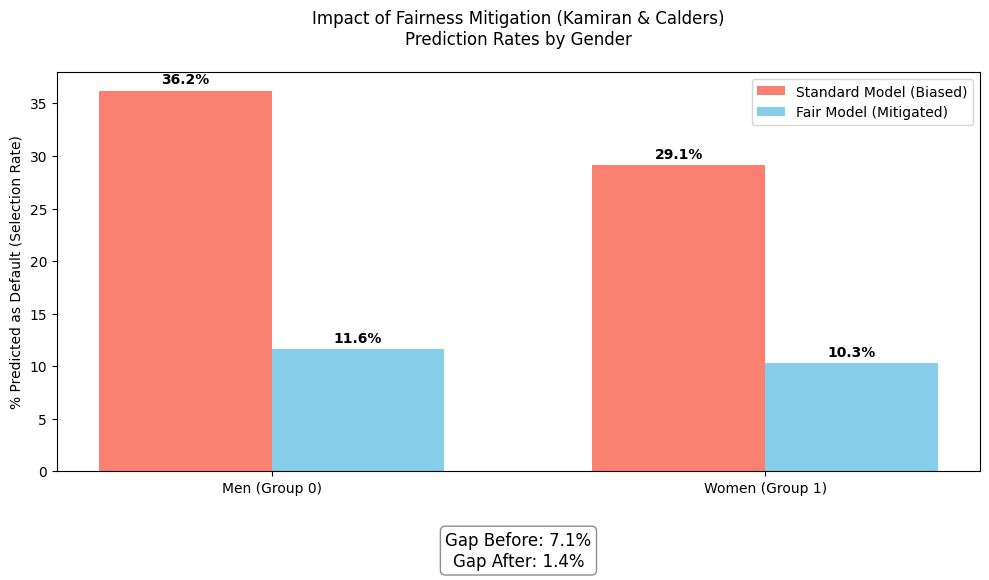

In [14]:
# Generate the visual comparison
plot_fairness_comparison(mf_before, mf_after)


--- Recommended weights to handle class imbalance ---
Class 0 -> 0.64
Class 1 -> 2.26
Calculating COMBINED weights (Fairness + Class Imbalance)

Starting PyTorch model training with Regularization...
Initial LR: 0.01, Epochs: 300, Dropout: 0.4
Epoch [20/300], Loss: 0.4866, Current LR: 0.009891
Epoch [40/300], Loss: 0.4638, Current LR: 0.009568
Epoch [60/300], Loss: 0.4539, Current LR: 0.009046
Epoch [80/300], Loss: 0.4474, Current LR: 0.008347
Epoch [100/300], Loss: 0.4445, Current LR: 0.007503
Epoch [120/300], Loss: 0.4397, Current LR: 0.006549
Epoch [140/300], Loss: 0.4392, Current LR: 0.005527
Epoch [160/300], Loss: 0.4376, Current LR: 0.004483
Epoch [180/300], Loss: 0.4361, Current LR: 0.003461
Epoch [200/300], Loss: 0.4354, Current LR: 0.002508
Epoch [220/300], Loss: 0.4361, Current LR: 0.001663
Epoch [240/300], Loss: 0.4350, Current LR: 0.000964
Epoch [260/300], Loss: 0.4348, Current LR: 0.000442
Epoch [280/300], Loss: 0.4327, Current LR: 0.000119
Epoch [300/300], Loss: 0.4337, 

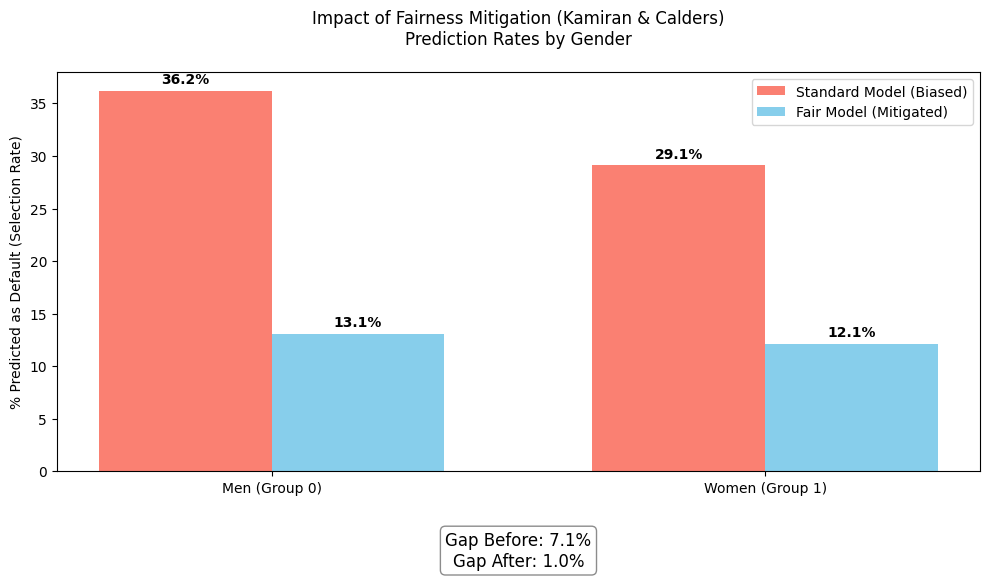

In [15]:
base_weights = analyzer.compute_model_weights() 
combined_weights = get_combined_weights(X_train, y_train, class_weights=base_weights)


master_model = train_model(
    X_train, 
    y_train, 
    epochs=300, 
    start_lr=0.01, 
    instance_weights=combined_weights, 
    dropout_p=0.4
)


print("\n--- master model audit ---")
mf_master = evaluate_fairness(master_model, X_test, y_test)

print("\n--- master model performance ---")
evaluate_model(master_model, X_test, y_test)


plot_fairness_comparison(mf_before, mf_master)

In [16]:
from src.model import evaluate_model_threshold
from src.fairness import evaluate_fairness_threshold

for seuil in [0.45, 0.40, 0.35, 0.30, 0.25]:
    print("-" * 50)

    evaluate_model_threshold(master_model, X_test, y_test, threshold=seuil)
    evaluate_fairness_threshold(master_model, X_test, y_test, threshold=seuil)

--------------------------------------------------

🎯 Performances avec Seuil = 45.0%
              precision    recall  f1-score   support

           0       0.85      0.92      0.89      4673
           1       0.62      0.43      0.51      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.68      0.70      6000
weighted avg       0.80      0.81      0.80      6000

Fairness (threshold = 45.0%) ->  Men/Women : 1.62%
--------------------------------------------------

🎯 Performances avec Seuil = 40.0%
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      4673
           1       0.58      0.47      0.52      1327

    accuracy                           0.81      6000
   macro avg       0.72      0.69      0.70      6000
weighted avg       0.80      0.81      0.80      6000

Fairness (threshold = 40.0%) ->  Men/Women : 3.68%
--------------------------------------------------

🎯 Performances avec 

In [17]:
from src.privacy import attack_mia, train_private_model


print("--- Security on Optimized MODEL ---")
mia_rate_master = attack_mia(optimized_model, X_train, y_train, X_test, y_test)

print("\n--- private model training ---")

private_model = train_private_model(X_train, y_train, class_weights=base_weights, epochs=15)


print("\n--- security test on private model ---")
mia_rate_private = attack_mia(private_model, X_train, y_train, X_test, y_test)


print("\n--- private model performance ---")

evaluate_model_threshold(private_model, X_test, y_test, threshold=0.35)

--- Security on Optimized MODEL ---

Phase 4: MIA Attack (Rule-Based) by Olivia...
MIA Attack Success Rate: 50.60%
Privacy preserved: The model is robust against this MIA (attacker is guessing randomly).

--- private model training ---

Phase 4: Differential Privacy Defense (DP-SGD)
Training private model (injecting mathematical noise)...


/Users/oliviamilano/Desktop/trustworthy-ai-project/.venv/lib/python3.11/site-packages/opacus/privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/Users/oliviamilano/Desktop/trustworthy-ai-project/src/privacy.py:85: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


Training complete! Privacy Budget Spent (Epsilon): 2.33

--- security test on private model ---

Phase 4: MIA Attack (Rule-Based) by Olivia...
MIA Attack Success Rate: 50.23%
Privacy preserved: The model is robust against this MIA (attacker is guessing randomly).

--- private model performance ---

🎯 Performances avec Seuil = 35.0%
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.64      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.68      6000
weighted avg       0.80      0.81      0.79      6000



array([0., 0., 0., ..., 0., 0., 0.], shape=(6000,), dtype=float32)

In [18]:
from src.robustness import attack_fgsm, train_robust_model, attack_fgsm_smart, attack_lowprofool
import torch 

/Users/oliviamilano/Desktop/trustworthy-ai-project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
# --- ACT 1 : ATTACK ---
X_test_corrupted = attack_fgsm(optimized_model, X_test, y_test, epsilon=0.2)

# --- ACTE 2 :  DEFENSE ---

robust_model = train_robust_model(
    X_train=X_train, 
    y_train=y_train, 
    baseline_model=optimized_model, 
    class_weights=base_weights,  
    epsilon=0.2, 
    epochs=300
)

# --- ACT 3 : L'EVALUATION ---
print("\n--- PERFORMANCES ROBUST MODEL ON SANE DATA ---")

evaluate_model_threshold(robust_model, X_test, y_test, threshold=0.35)

print("\n--- PERFORMANCE ROBUST MODEL ON CORRUPTED DATA ---")

robust_model.eval()
with torch.no_grad():
    outputs_defense = robust_model(X_test_corrupted)
    predictions_defense = (torch.sigmoid(outputs_defense) >= 0.35).float().numpy().flatten()

from sklearn.metrics import classification_report
print(classification_report(y_test, predictions_defense))


Phase 3: Starting FGSM Adversarial Attack with epsilon=0.2...
Generating adversarial examples (Perturbation epsilon = 0.2)...
Accuracy under FGSM attack: 80.57%

Phase 3: Defense via Adversarial Training
Generating poison on training data (this may take a few seconds)...
Training the robust shield model...
Robust training complete.

--- PERFORMANCES ROBUST MODEL ON SANE DATA ---

🎯 Performances avec Seuil = 35.0%
              precision    recall  f1-score   support

           0       0.93      0.38      0.54      4673
           1       0.29      0.90      0.44      1327

    accuracy                           0.49      6000
   macro avg       0.61      0.64      0.49      6000
weighted avg       0.79      0.49      0.52      6000


--- PERFORMANCE ROBUST MODEL ON CORRUPTED DATA ---
              precision    recall  f1-score   support

           0       0.91      0.49      0.64      4673
           1       0.32      0.83      0.46      1327

    accuracy                           

In [20]:
from sklearn.metrics import classification_report

# --- 1. EXECUTE THE SMART ATTACK ---
# We pass the column names so the attack knows which features to freeze (categorical) 
# and which ones to perturb (continuous).
X_test_corrupted_smart = attack_fgsm_smart(
    model=optimized_model, 
    X_test=X_test, 
    y_test=y_test, 
    X_test_columns=X_test.columns
)

# --- 2. EVALUATE BUSINESS IMPACT ---
print("\n--- PERFORMANCE OF MASTER MODEL UNDER SMART ATTACK ---")


master_model.eval()
with torch.no_grad():
    outputs_smart_attack = optimized_model(X_test_corrupted_smart)
    predictions_smart_attack = (torch.sigmoid(outputs_smart_attack) >= 0.35).float().numpy().flatten()


print(classification_report(y_test, predictions_smart_attack))


Phase 3: Starting Smart FGSM Attack
Generated max perturbation vector (Epsilons): [0.1 0.  0.  0.  0.1 0.  0.  0.  0.  0.  0.  0.1 0.1 0.1 0.1 0.1 0.1 0.
 0.  0.  0.  0.  0. ]
Generating stealthy adversarial examples
Accuracy under Smart FGSM attack: 76.15%


--- PERFORMANCE OF MASTER MODEL UNDER SMART ATTACK ---
              precision    recall  f1-score   support

           0       0.90      0.57      0.70      4673
           1       0.34      0.79      0.48      1327

    accuracy                           0.62      6000
   macro avg       0.62      0.68      0.59      6000
weighted avg       0.78      0.62      0.65      6000



In [21]:
X_test_corrupted_lpf = attack_lowprofool(
    model=optimized_model, 
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    y_test=y_test
)

print("\n--- PERFORMANCE SOUS ATTAQUE LOWPROFOOL ---")
optimized_model.eval()

with torch.no_grad():

    outputs_lpf = optimized_model(X_test_corrupted_lpf)
    predictions_lpf = (torch.sigmoid(outputs_lpf) >= 0.35).float().numpy().flatten()


print(classification_report(y_test, predictions_lpf))

Advanced Stealth Attack (LowProFool)
Analyzing training data structure to find blind spots...
Generating undetectable mutants...


LowProFool: 100%|██████████| 50/50 [00:00<00:00, 51.95it/s]


Global Accuracy under LowProFool attack: 73.58%


--- PERFORMANCE SOUS ATTAQUE LOWPROFOOL ---
              precision    recall  f1-score   support

           0       0.93      0.44      0.60      4673
           1       0.31      0.88      0.46      1327

    accuracy                           0.54      6000
   macro avg       0.62      0.66      0.53      6000
weighted avg       0.79      0.54      0.57      6000



In [22]:
from src.robustness import train_robust_model_lpf

robust_model_lpf = train_robust_model_lpf(
    X_train=X_train, 
    y_train=y_train, 
    baseline_model=optimized_model, 
    class_weights=base_weights, 
    epochs=300
)

print("\n--- PERFORMANCE FACING LOWPROFOOL ---")
robust_model_lpf.eval()
with torch.no_grad():

    outputs_defense = robust_model_lpf(X_test_corrupted_lpf)
    predictions_defense = (torch.sigmoid(outputs_defense) >= 0.35).float().numpy().flatten()

from sklearn.metrics import classification_report
print(classification_report(y_test, predictions_defense))


 Creation of the Ultimate Shield (Adversarial Training LPF)
Analyzing the structure of the training data...


LowProFool: 100%|██████████| 50/50 [00:03<00:00, 13.34it/s]


Training the robust shield model...
LowProFool shield activated and model trained.

--- PERFORMANCE FACING LOWPROFOOL ---
              precision    recall  f1-score   support

           0       0.92      0.46      0.61      4673
           1       0.31      0.85      0.45      1327

    accuracy                           0.55      6000
   macro avg       0.61      0.66      0.53      6000
weighted avg       0.78      0.55      0.58      6000



In [23]:
print("\n--- OPTIMAL THRESHOLD FOR LPF ---")
robust_model_lpf.eval()


with torch.no_grad():
    outputs_defense = robust_model_lpf(X_test_corrupted_lpf)
    probabilities = torch.sigmoid(outputs_defense)


for seuil in [0.65, 0.60, 0.55, 0.50, 0.45, 0.40, 0.35]:
    print(f"\n{'='*40}")
    print(f" TEST  = {seuil*100}%")
    print(f"{'='*40}")
    
    predictions_defense = (probabilities >= seuil).float().numpy().flatten()
    

    print(classification_report(y_test, predictions_defense))


--- OPTIMAL THRESHOLD FOR LPF ---

 TEST  = 65.0%
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      4673
           1       0.58      0.46      0.51      1327

    accuracy                           0.81      6000
   macro avg       0.72      0.68      0.70      6000
weighted avg       0.79      0.81      0.80      6000


 TEST  = 60.0%
              precision    recall  f1-score   support

           0       0.86      0.88      0.87      4673
           1       0.54      0.51      0.53      1327

    accuracy                           0.80      6000
   macro avg       0.70      0.69      0.70      6000
weighted avg       0.79      0.80      0.79      6000


 TEST  = 55.00000000000001%
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      4673
           1       0.50      0.57      0.53      1327

    accuracy                           0.78      6000
   macro avg       0.68      0.7